# Plotting of double-differential cross sections

This notebook showcases the plotting of a double-differential cross section (ddx) extracted from an ENDF-6 file. To achieve this, we perform the following steps:

1) Load the necessary packages
2) Read the ENDF-6 file into a Python dictionary
3) Specify the reaction for which the ddx should be plotted
4) Specify three arrays with the incident energies, emitted energies and angles of interest
5) Invoke the function `compute_ddxs` to extract a cube (=three dimensional array)
6) Plot it! :-)

For this example, we pick **beryllium-9** from the **ENDF/B-VIII.1** library and plot the double-differential cross sections for **neutrons** produced in an **(n,2n)** reaction, both as 2d and 3d plot. In addition, some helpful functions for querying the reactions available in an ENDF file will be explained, too.

## Loading the necessary packages

First, we load **numpy** and **pandas** for convenient data manipulation and **pyplot** for plotting:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# comment out %matplotlib directive for static plots
# widget option requires ipympl package
%matplotlib widget

The **EndfParserCpp** class will be used for loading the data from an ENDF-6 file into a Python dictionary:

In [2]:
from endf_parserpy import EndfParserCpp

**deg2rad** is a simple convenience function to convert degrees to radians. The function **get_reaction_string_for_mt** translates MT numbers to string representations of the nuclear reactions:

In [3]:
from endf_userpy.helpers import deg2rad
from endf_userpy.reactions import get_reaction_string_for_mt

The following imported functions query information about reactions:

- **get_QI** returns the reaction Q-value
- **get_reactions** returns the reaction strings of available reactions
- **get_reaction_mts** retuns the MT numbers of available reactions
- **get_incident_energy_range** returns lower and upper limit of a reaction
- **get_zaps_for_mt** returns all the reaction product (as **Z\*1000 + A**) for a reaction referenced by **MT** number

In [4]:
from endf_userpy.properties import get_QI
from endf_userpy.mf3_interpretation import (
    get_reactions,
    get_reaction_mts,
    get_incident_energy_range,
)
from endf_userpy.mf6_interpretation_helpers import (
    get_zaps_for_mt,
)

The **compute_xs** function retrieves the cross sections (in the laboratory system) of a reaction for a user-specified mesh of incident energies, adhering rigorously to the interpolation scheme specified in the ENDF file.

In [5]:
from endf_userpy.quantities import compute_xs

The **compute_ddxs** function is the real champion of this notebook. It retrieves the double-differential cross section in the laboratory system associated with an ejectile from a nuclear reaction. The user specifies a cartesian mesh defined by three 1d meshes of incident energies, emitted energies, and angle cosines (**mu**), respectively. All of these quantities refer to the laboratory system.

This function performs all the required 1-dim, 2-dim and 3-dim interpolations, reconstructs the ddx distribution from Legendre polynomials, and converts the result into the laboratory system.

In [6]:
from endf_userpy.quantities import compute_ddxs

## Loading the ENDF data

We use the functionality of the **endf-parserpy** package to load the data from the ENDF file into a Python dictionary:

In [7]:
endf_file = os.path.join('..', 'tests', 'data', 'n-004_Be_009.endf')
parser = EndfParserCpp()
endf_dict = parser.parsefile(endf_file)

To get an idea about the ENDF file, we create a pandas DataFrame that shows the available reactions and their associated MT numbers:

In [8]:
reacs = get_reactions(endf_dict)
reac_mts = get_reaction_mts(endf_dict)
reac_dt = pd.DataFrame({'reaction': reacs, 'mt': reac_mts}).set_index('mt')
reac_dt

,reaction
mt,
1,"(n,total)"
2,"(n,n_0)"
3,"(n,nonelas)"
16,"(n,2n)"
102,"(n,g)"
103,"(n,p)"
104,"(n,d)"
105,"(n,t)"
107,"(n,a)"


In this notebook, we want to plot the double-differential cross section for neutrons produced by the **(n,2n)** reaction. To get an idea about the viable incident energy range of this reaction, let's compute the total **(n,2n)** cross section on a dense mesh of inident energies first. The **get_energy_range** function is helpful in this regard to obtain the lower and upper limit of the reaction.

In [9]:
mt = 16
energy_range = get_incident_energy_range(endf_dict, 16)
energies = np.linspace(energy_range[0], energy_range[1], 1000) 
xs = compute_xs(endf_dict, 16, energies)

Let's plot the cross section. For convenience, we'll use **MeV** and **mbarn** for plotting.

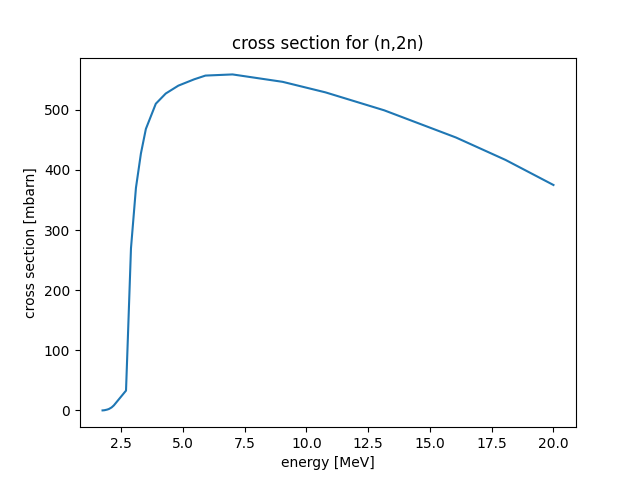

In [10]:
plt.plot(energies / 1e6, xs * 1e3)
plt.title(f'cross section for {reac_dt.at[mt, "reaction"]}')
plt.xlabel('energy [MeV]')
plt.ylabel('cross section [mbarn]')
plt.show()

## Plotting the double-differential cross section

For plotting the double-differential cross section of a reaction, it is a good idea to see for which reaction products double-differential distributions are available. We'll use the **get_zaps_for_mt** function to retrieve a list of **ZAP** values for the reaction. A **ZAP** is specified by `Z*1000 + A` with **Z** the charge number and **A** the mass number of the reaction product. The `dist2d_only=True` option ensures that only reaction products are returned for which double-differential distributions are available.

In [11]:
zaps = get_zaps_for_mt(endf_dict, mt, dist2d_only=True)
print(zaps)

[1.0, 2004.0]


From this result, we see that a double-differential distribution for a neutron (ZAP=1) is available.

Now we specify a 3-dim mesh that is the cartesian product of the 1-dim meshes for incident energy, emitted energy and angle-cosines. In this notebook, we'll only use a single incident energy (**cur_energy**) for the incident mesh. For the emission energies, we define a mesh that goes from a very small value up to the incident energy plus the reaction Q-value so we capture all non-zero ddx values.

In [12]:
cur_energy = 5e6
qval = get_QI(endf_dict, mt) 
energies_in = np.array([cur_energy])
energies_out = np.linspace(1e-10, cur_energy+qval, 1000)  
angle_cosines_out = np.linspace(-1, 1, 1000)

With these specifications of the 1d meshes, we can invoke **compute_ddxs** to obtain a three dimensional array (a cube) with all the ddx values.

In [13]:
ddx_values = compute_ddxs(endf_dict, mt, zaps[0], energies_in, energies_out, angle_cosines_out)

By now, everything is ready for a nice 3d plot of the double-differential cross section. The **np.meshgrid** function produces the cartesian product mesh required by **plot_surface**.

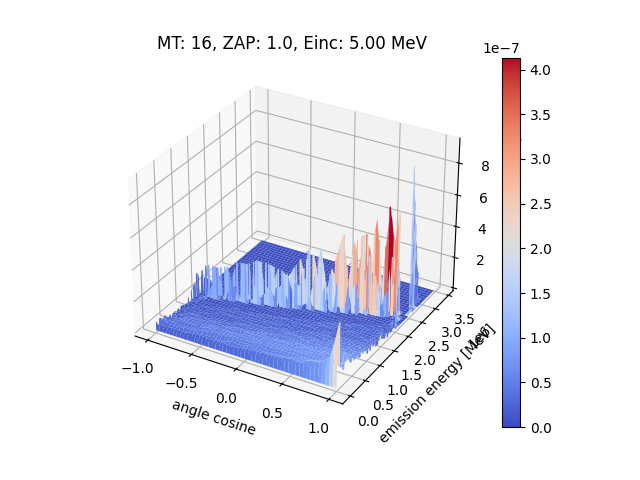

In [14]:
# make a beautiful 3d plot
Z_values = ddx_values[0,:,:]
X, Y = np.meshgrid(angle_cosines_out, energies_out) 
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_values, cmap='coolwarm', edgecolor='none')
# ax.set_zscale('log')
fig.colorbar(surf)
plt.title(f'MT: {mt}, ZAP: {zaps[0]}, Einc: {cur_energy/1e6:.2f} MeV')
plt.xlabel('angle cosine')
plt.ylabel('emission energy [MeV]')
plt.show()

As beautiful as this 3d plot looks, it is difficult to interpret it quantitatively. Therefore, let's compute another ddx value cube where we only supply the angle cosine corresponding to 60 degree. Because we know by construction that this cube is of dimension 1 x 10000 x 1, we immediately flatten the result to a 1-dim numpy array.

In [15]:
ens_in = np.array([5e6])
ang_out = 60
ens_out = np.linspace(1e-5, 3.5e6, int(1e4))
ddxvals = compute_ddxs(
    endf_dict, mt, zaps[0], ens_in, ens_out,
    np.cos([deg2rad(ang_out)])
).flatten()

Plotting this data, we see in better detail how the slice at angle cosine=0.5 (60 deg) in the three-dimensional plot above evolves as a function of emitted energy.

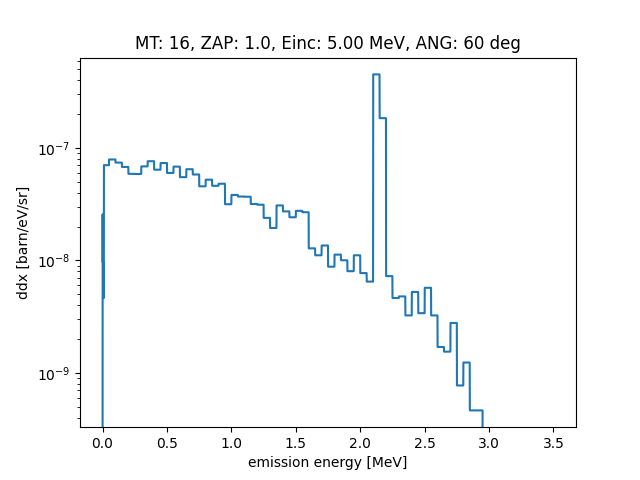

In [16]:
plt.figure()
plt.plot(ens_out / 1e6, ddxvals)
plt.yscale('log')
plt.title(f'MT: {mt}, ZAP: {zaps[0]}, Einc: {ens_in[0]/1e6:.2f} MeV, ANG: {ang_out} deg')
plt.xlabel('emission energy [MeV]')
plt.ylabel('ddx [barn/eV/sr]')
plt.show()

## Summary

This notebook demonstrated how double-differential cross sections can be computed using the **compute_ddxs** function. The user passes three one-dimensional arrays for the incident energy, emitted energy and angle cosine (all in the lab-system) to the function and obtains a three-dimensional array (a cube) with the resulting ddx values (also in the lab-system). Importantly, even though ddx data can be stored in [various representations][1] in an ENDF-6 file, a user doesn't need to concerned with these details anymore.


[1]: https://www.nndc.bnl.gov/endfdocs/ENDF-102-2023.pdf#page=152